<center>
    <img src="https://rockborne.com/wp-content/uploads/2021/07/LandingPage-Header-RED-CENTRE.jpg" width="900" alt="logo"  />
</center>

# Brain Stroke Prediction (Student)

*Project · Student version*

<!-- about-data:auto -->
## About the data

**Patient health records; the task is to predict stroke (see the project brief for the full brief).**

Source: [Kaggle: Brain Stroke Dataset](https://www.kaggle.com/datasets/jillanisofttech/brain-stroke-dataset)

| Column | Description |
|---|---|
| `gender` | Male / Female |
| `age` | Age in years |
| `hypertension` | 0/1 |
| `heart_disease` | 0/1 |
| `ever_married` | Yes / No |
| `work_type` | Employment type |
| `Residence_type` | Urban / Rural |
| `avg_glucose_level` | Average blood glucose |
| `bmi` | Body mass index |
| `smoking_status` | Smoking status |
| `stroke` | Target. 1 = had a stroke, 0 = did not |

## About this project

Predict `stroke` (a classification task) on `brain_stroke_data.csv`, then predict the target for `brain_stroke_unseen.csv` and submit `name_surname_brain_stroke.csv` (one column `Predictions`). See `Project_Brief_BrainStroke.md` for the full rules and marking scheme. The data is imbalanced (~5% stroke), so the leaderboard uses **F1 on the stroke class**, not accuracy. Data is in `../../../datasets/Session_5/projects_datasets/` (also on the public S3 bucket at `https://rockborne-bucket-01-cbs.s3.eu-west-2.amazonaws.com/Data_Sources_CBS_Risk/Session_5/projects_datasets/`).

## 1. Setup and load
Import your libraries and load `../../../datasets/Session_5/projects_datasets/brain_stroke_data.csv`. Take a first look.

In [1]:

import pandas as pd
import numpy as np

# visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# models
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# imbalance handling
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    precision_score,
    recall_score
)

from sklearn.model_selection import cross_validate


# settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')


## 2. Data quality
Check dtypes, missing values, duplicates, and the `stroke` balance. Note what you find.

In [2]:
# importing data 

df_train = pd.read_csv('brain_stroke_data.csv')

We begin by running a few diagnostics on the dataset to understand what we're working with. 

In [3]:
# initial info

df_train.info()

print(df_train.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4482 entries, 0 to 4481
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             4482 non-null   object 
 1   age                4482 non-null   float64
 2   hypertension       4482 non-null   int64  
 3   heart_disease      4482 non-null   int64  
 4   ever_married       4482 non-null   object 
 5   work_type          4482 non-null   object 
 6   Residence_type     4482 non-null   object 
 7   avg_glucose_level  4482 non-null   float64
 8   bmi                4482 non-null   float64
 9   smoking_status     4482 non-null   object 
 10  stroke             4482 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 385.3+ KB
0


The initial check is actually very promising. We find no missing values in any of the columns, and every column is read in as the right type. Additionally, there are no duplicated rows. 

The next step is to confirm the class balance.

In [4]:
df_train['stroke'].value_counts(normalize = True)

stroke
0    0.950245
1    0.049755
Name: proportion, dtype: float64

We have just under 5% strokes in the dataset.

It's worth noting that this equates to just over 200 positive cases given the size of our dataset. That is not much to go off, and suggests that some SMOTE might be neccesary further down the pipeline. 

I now move on to check the categories in each of the categorical variables.

In [5]:
for col in ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']:
    print(col, df_train[col].unique())

gender ['Female' 'Male']
ever_married ['Yes' 'No']
work_type ['Private' 'Self-employed' 'Govt_job' 'children']
Residence_type ['Urban' 'Rural']
smoking_status ['smokes' 'Unknown' 'formerly smoked' 'never smoked']


Again this dataset is proving to be remarkably clean. There are no hidden typos or innacuracis. The only thing worth noting is that in the `smoking_status` column, 'Unknown' is spelt with a capital letter wheras all of the other categories are lower case. Thisis really quite trivial though.

I now check the numerical columns' ranges, and the binary column values>

In [6]:
df_train[['age', 'avg_glucose_level', 'bmi']].describe()

,age,avg_glucose_level,bmi
count,4482.000000,4482.000000,4482.000000
mean,43.446693,105.761430,28.466064
std,22.592327,44.943627,6.764658
min,0.080000,55.120000,14.000000
25%,26.000000,77.192500,23.600000
50%,45.000000,91.680000,28.100000
75%,61.000000,113.637500,32.575000
max,82.000000,267.760000,48.900000


This mostly seems okay, but for the minimum age value that is '0.08'. This could be a new born, but is highly likely to be an outlier, and why on earth would someone record it as '0.08'. I will investigate further.

In [7]:
df_train[df_train['age'] < 2].sort_values('age')

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
1626,Female,0.08,0,0,No,children,Urban,139.67,14.1,Unknown,0
398,Male,0.08,0,0,No,children,Rural,70.33,16.9,Unknown,0
4209,Male,0.16,0,0,No,children,Urban,114.71,17.4,Unknown,0
2116,Male,0.24,0,0,No,children,Urban,57.09,19.4,Unknown,0
2237,Male,0.24,0,0,No,children,Urban,89.28,14.2,Unknown,0
...,...,...,...,...,...,...,...,...,...,...,...
712,Male,1.88,0,0,No,children,Rural,68.35,19.1,Unknown,0
3163,Male,1.88,0,0,No,children,Rural,77.91,21.8,Unknown,0
2482,Female,1.88,0,0,No,children,Rural,100.74,18.6,Unknown,0
3382,Male,1.88,0,0,No,children,Rural,143.97,19.0,Unknown,0


Interestingly, the dataset seems to be recording children's ages as fractions. This is okay in and of itself, but the problem it causes is with the other variables such as `ever_married`, `hypertension`, and `smoking_status`. Obviously children cannot tick yes for any of these, so its very likely that we have some colinearity between those variables with `age` at the low end. 

To be honest, I am not entirely sure how best to address this issue. Perhaps we introduce a separate child category for those variables too in order to address the problem. This will shed the colinearity problem, but introduce another one because th information that a participant is a child is already encoded both in age and `work_type`. 

For now I will do nothing because this is a feature of the dataset and not something with an easy fix. If I later go onto use a model which is highly sensitive to colinearity, I will consider dropping a column or another fix. 

For now we can move on to check whether the binary columns contain only 0s and 1s

In [8]:
for col in ['hypertension', 'heart_disease', 'stroke']:
    print(col, df_train[col].unique())

hypertension [0 1]
heart_disease [0 1]
stroke [0 1]


Awesome, all good on that front. Data quality checks have been completed. The dataset is surprisingly clean.

We can now move on to EDA.


## 3. EDA

I keep my EDA focused on anything that is likely to affect the model's performance on the F1 score. I will examine the following thre categories.

1. Stroke vs Non-stroke distributions for the continuous variables

2. Stroke rates by category 

3. Correlation matrices (briefly)



##### Distribution analysis

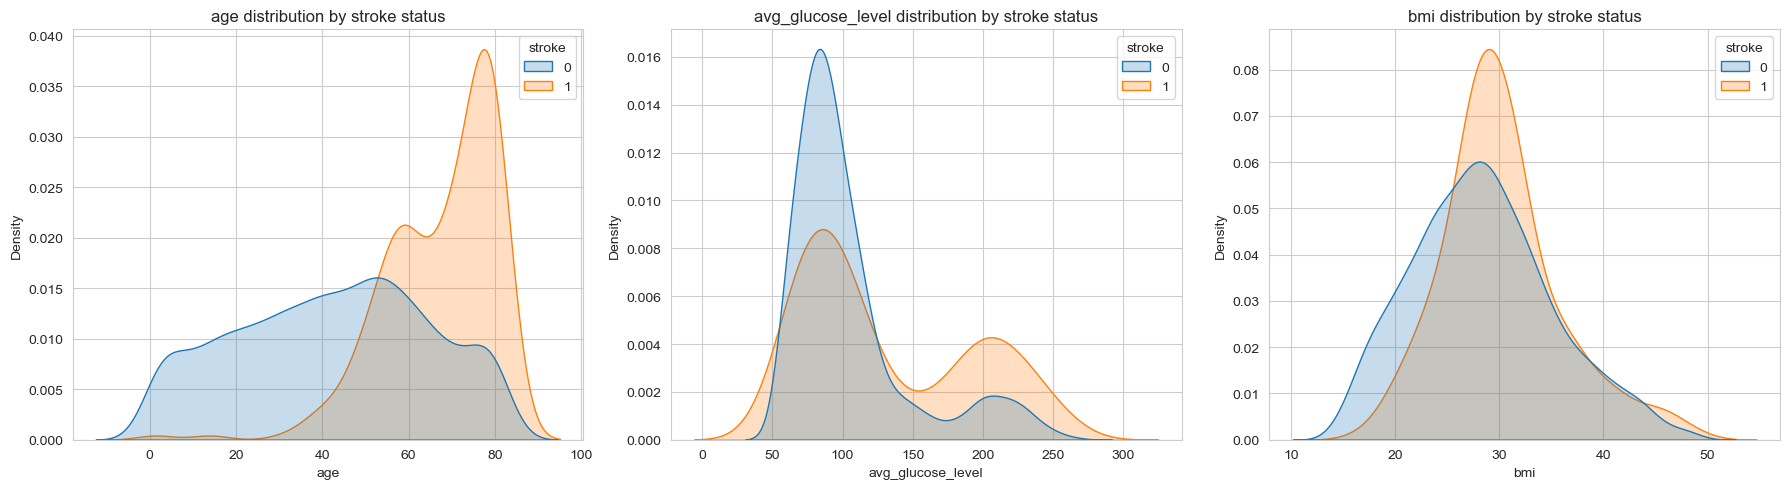

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ['age', 'avg_glucose_level', 'bmi']):
    sns.kdeplot(data=df_train, x=col, hue='stroke', common_norm=False, fill=True, ax=ax)
    ax.set_title(f'{col} distribution by stroke status')

plt.tight_layout()
plt.show()

Lets briefly examine what the charts show.

As we would expect, age for stroke cases is skewed right, and those who have a stroke are on average of a much higher age. There is a long left tail of strokes for those who are under 40. Age is likely to be a strong predictor.

Interestingly, glucose level is bimodal for both categories, perhaps the density plot is piking up two separate populations within the dataset, those with normal blood glucose levels and those with diabetic levels. It is clear that the stroke patients have a larger percentage of their population made up of those with diabetic level blood pressure. This is expected and easy to understand.

Another consequence of this finding though is that we would expect a linear model such as logit to underperform for this dataset. Logit computes a linear regression boundary, which would completely miss the bimodal nature of the variable. Thus I would lean towards some model which can capture non-linearities.

Finally, bmi appears to be a weak predictor. It shows a visually modest difference between the two classes, which may not translate well into strong predictive contributions.



##### Stroke rate by categories

I will take a look at how stroke rates change based on each of the categorical variables.

In [10]:
cat_cols = ['hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'smoking_status', 'gender']

for col in cat_cols:
    print(df_train.groupby(col)['stroke'].agg(['mean', 'count']))
    print()

                  mean  count
hypertension                 
0             0.040831   4041
1             0.131519    441

                   mean  count
heart_disease                 
0              0.042955   4237
1              0.167347    245

                  mean  count
ever_married                 
No            0.016329   1531
Yes           0.067096   2951

                   mean  count
work_type                     
Govt_job       0.051020    588
Private        0.050564   2571
Self-employed  0.084605    721
children       0.003322    602

                    mean  count
Residence_type                 
Rural           0.045909   2200
Urban           0.053462   2282

                     mean  count
smoking_status                  
Unknown          0.031805   1352
formerly smoked  0.081686    759
never smoked     0.047447   1665
smokes           0.055241    706

            mean  count
gender                 
Female  0.048462   2600
Male    0.051541   1882



This result mostly aligns with my expectations, with a few nuances to discuss. 

For starters we see significant differences in stroke rates for those in the dataset with a heart disease or hypertension, whih is exactly as we would expect. 

There are no significant differences in the rates for `rsidence_type` or `gender`, which is also what we would expect.  

Children show a near zero stroke risk, and those who are self-employed do show a meaningful increase in stroke representation. This could be an independent signal, or it couldbe that those who are self-employed simply skew older. 

Interestingly, former smokers show a higher stroke likelihood (8.2%), markedly higher than never smoked and smokes. It is interesting that currrent smokers do not show elevated stroke risk; this could be a quirk of our small sample size, or it could be that most smokers are younger than those who have smoked and quit. Again, it is unclear how much of these differences are independant signalsor are getting tied up with age. 

Another curious result is that those who have never married show a much lower risk of stroke (1.6% compared to 6.7%). While on the surface this looks important, I would argue that it is very clear that this is an age driven effect. Those who have never married skew much younger, and stroke risk is overwhelmingly age driven.

I will investigate this effect further below, and if there exists a high enough correlation it might be worth removing this variable from the dataset in its entirety, loathe as I am to prune our already scant feature space.  

In [11]:
df_train.groupby('ever_married')['age'].median()

ever_married
No     18.0
Yes    54.0
Name: age, dtype: float64

The result above is clear; the signal that ever_married was sending was primarily age driven. Of course if the average age of the classes differ this much we would see what appears to be a strong signal. Indeed, a brief glanceat our density plots above show that almost no stroke cases happen for those below the age of 35. 

This analysis is damning enough to conclude that this variable should be removed for any linear models. I will not do so now however so as to keep the pipeline stages distinct, and also because other model families are much less snsitive to co-linearity in the dataset. 

Many of our variables appear to have a correlation with Age, so it is becoming increasingly unlikely that I will opt for a linear model.

##### Correlation matrices


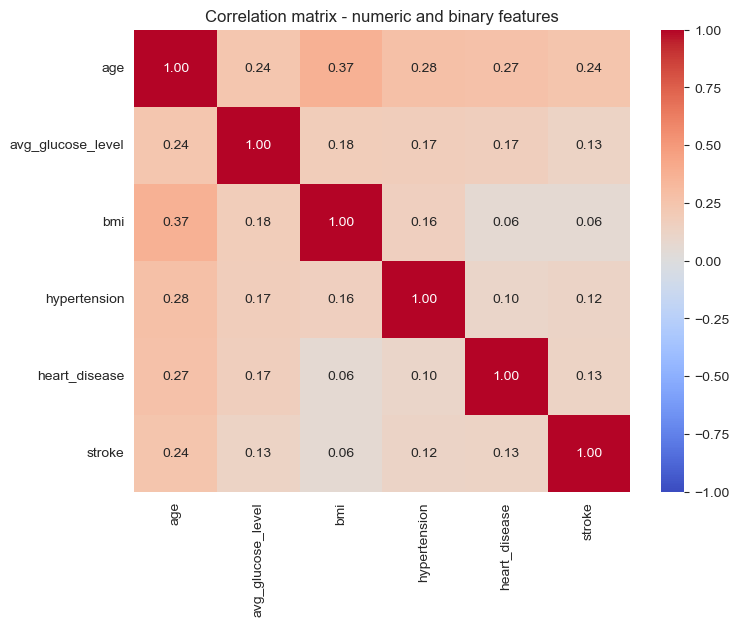

In [12]:
# correlation matrix - numeric and binary features only
num_cols = ['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease', 'stroke']

corr_matrix = df_train[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlation matrix - numeric and binary features')
plt.show()

**DECIDE WHETHER TO KEEP ABOVE MATRIX SEEMS UNECCESARY** 

#### EDA summary

- Age is the dominant predictor of stroke risk. 
- Avg_glucose_level shows a bimodal relationship with stroke.
- Several other features (ever_married, work_type, smoking_status) are substantially confounded with age rather than independently predictive.
- Hypertension and heart_disease show strong relative risk elevation (3-4x) despite weaker linear correlation.
- The bimodal glucose pattern and the age-driven colinearity present in multiple features suggest that a tree based model is most appropriate for this problem. I am leaning towards a mode such as XGboost which is known for handling imbalanced datasets well.
- Logistic regression is still a candidate for an interpretable baseline; I will run several regressions, starting with just age as a predictor, and then including several more based on their VIF scores.

## 4. Preprocessing

The pre-processing steps in this project are MUCH easier than the plane project. It is simply a case of one hot encoding categorical variables, and scaling the numerical variables for the logit pipeline. Tree based models split the data based on thresholds, so no scaling is needed.

We confirmed that there are no missing values in any of the columns, so imputation is unnecessary. I briefly considered outlier removal, but rejected it. Per the data summaries earlier, the most extreme points were all clinically possible, and the age issue turned out to be real children. 

As such the data cleaning and feature engineering neccesary turns out to be very simple, and we can build a pipeline immediately. The only question is whether to use SMOTE. I will likely experiment with SMOTE to see if it improves the model, and will run a model with and without SMOTE. 

However SMOTE needs to sit outside of the pre-processing pipeline so that it has access to the full engineered feature space. Therefore, it is a downstream consideration. For now we can begin buidling the data cleaning and feature engineering pipeline. 

In [13]:
# setting the random state to be the answer to the ultimate question 
# of life, the universe, and everything

random_state = 42



In [14]:
# start by separating the target and features

X = df_train.drop(columns = 'stroke')

y = df_train['stroke']

# separate different categories of features

numeric = ['age', 'avg_glucose_level', 'bmi']
categorical = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

# defining the exact class ratio for pre-processing that needs this later on

class_ratio = (y == 0).sum() / (y == 1).sum()

print(class_ratio)


19.09865470852018


Here I begin to separate the logistic regression pipeline and the tree-based pipeline. 

I will use XGBoost, since my research suggests that this is industry standard for imbalanced dataframes because it includes native class imbalance scaling by altering the amount by which it penalises mistakes. And have logistic regression as a baseline model. I will also build separate pipelines which include no rsampling but using XGboosts native scaling, SMOTE, and random-undersampling. 

I can also compare this to random forest approaches.

#### Logit Pre-processing and Pipeline

Logit needs scaling on numeric features because it is sensitive to feature magnitude. I will simply apply standardisation to the numerical features and one hot encode the categorical features. 

In [15]:
# global categorical one-hot-encoder

categorical_encoder = OneHotEncoder(drop = 'first', handle_unknown = 'ignore')

# logit pre-processor

logit_preprocessor = ColumnTransformer([
    ('numeric', StandardScaler(), numeric),
    ('categorical', categorical_encoder, categorical)
], remainder = 'passthrough')

In [16]:
# logit pipeline 

# much simpler this time around, simply tell it to preprocess using 
# the above pre-processor and then define thelogit classifier

logit_pipeline = Pipeline([
    ('preprocessor', logit_preprocessor),
    ('classifier', LogisticRegression(class_weight = 'balanced', max_iter = 1000, random_state = random_state))
])


#### XGBoost pre-processing and pipelines

Building the simpler preprocessor and the three aforementioned XGBoost pipelines.



In [17]:
# XGBoost preprocessor

xgb_preprocessor  = ColumnTransformer([
    ('categorical', categorical_encoder, categorical)
], remainder = 'passthrough')

In [18]:
# scale_pos_weight, no resampling
xgb_pipeline = Pipeline([
    ('preprocessor', xgb_preprocessor),
    ('classifier', XGBClassifier(scale_pos_weight=class_ratio, random_state=42, eval_metric='logloss'))
])

# SMOTE, no scale_pos_weight
xgb_smote_pipeline = ImbPipeline([
    ('preprocessor', xgb_preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(random_state=42, eval_metric='logloss'))
])

# random undersampling
xgb_undersample_pipeline = ImbPipeline([
    ('preprocessor', xgb_preprocessor),
    ('undersample', RandomUnderSampler(random_state=42)),
    ('classifier', XGBClassifier(random_state=42, eval_metric='logloss'))
])

Finally, we're going to be using K-fold cross validation to maximise our limited data size, so I will quickly set this up below. It is usefil to mention that I amusing a stratified K-fold approach to ensure that we have the same number of positive stroke cases in each set.

In [19]:
cv = StratifiedKFold(n_splits = 5, shuffle =True, random_state = random_state)

scoring = ['f1', 'precision', 'recall']

## 5. Models and evaluation
Train and compare at least two classifiers. Report the classification report, confusion matrix, precision, recall, F1 and ROC AUC. Focus on recall/F1 for the stroke class.

In [20]:

pipelines = {
    'Logistic Regression': logit_pipeline,
    'XGBoost (scale_pos_weight)': xgb_pipeline,
    'XGBoost (SMOTE)': xgb_smote_pipeline,
    'XGBoost (undersample)': xgb_undersample_pipeline
}

results = {}

for name, pipe in pipelines.items():
    cv_result = cross_validate(pipe, X, y, cv=cv, scoring=scoring)
    results[name] = {
        'F1': cv_result['test_f1'].mean(),
        'Precision': cv_result['test_precision'].mean(),
        'Recall': cv_result['test_recall'].mean(),
        'F1_std': cv_result['test_f1'].std()
    }
    print(f'{name}: F1 = {cv_result["test_f1"].mean():.4f} (+/- {cv_result["test_f1"].std():.4f}), '
          f'Precision = {cv_result["test_precision"].mean():.4f}, '
          f'Recall = {cv_result["test_recall"].mean():.4f}')

results_df = pd.DataFrame(results).T
results_df

Logistic Regression: F1 = 0.2314 (+/- 0.0113), Precision = 0.1348, Recall = 0.8159
XGBoost (scale_pos_weight): F1 = 0.1974 (+/- 0.0765), Precision = 0.2191, Recall = 0.1838
XGBoost (SMOTE): F1 = 0.0652 (+/- 0.0708), Precision = 0.1301, Recall = 0.0444
XGBoost (undersample): F1 = 0.1944 (+/- 0.0096), Precision = 0.1124, Recall = 0.7218


,F1,Precision,Recall,F1_std
Logistic Regression,0.231403,0.134849,0.815859,0.011292
XGBoost (scale_pos_weight),0.197384,0.219122,0.183838,0.076535
XGBoost (SMOTE),0.065212,0.130124,0.044444,0.070814
XGBoost (undersample),0.194412,0.112364,0.721818,0.009595


In [21]:
## hyperparamater tuning XGBOOST

from sklearn.model_selection import GridSearchCV

param_grid = {
    'classifier__max_depth': [3, 4, 5, 6],
    'classifier__n_estimators': [100, 200, 300],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__min_child_weight': [1, 3, 5]
}

In [22]:
grid_search = GridSearchCV(
    xgb_pipeline,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X, y)

print('Best F1:', grid_search.best_score_)
print('Best params:', grid_search.best_params_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best F1: 0.24922325553590619
Best params: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 6, 'classifier__min_child_weight': 3, 'classifier__n_estimators': 100}


In [23]:
# tuning the prediction threshold

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve

# rebuild the pipeline with the winning params from the grid search
best_xgb_pipeline = Pipeline([
    ('preprocessor', xgb_preprocessor),
    ('classifier', XGBClassifier(
        scale_pos_weight=class_ratio,
        max_depth=6,
        n_estimators=100,
        learning_rate=0.05,
        min_child_weight=3,
        random_state=42,
        eval_metric='logloss'
    ))
])

# out-of-fold predicted probabilities - method='predict_proba' returns [P(class0), P(class1)]
y_proba = cross_val_predict(best_xgb_pipeline, X, y, cv=cv, method='predict_proba')[:, 1]

In [24]:
# finding the threshold that maximises F1 for XGBOOST

precisions, recalls, thresholds = precision_recall_curve(y, y_proba)

# F1 = 2 * (precision * recall) / (precision + recall), computed at every threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)  # avoid div by zero

best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]

print(f'Best threshold: {best_threshold:.4f}')
print(f'F1 at best threshold: {f1_scores[best_idx]:.4f}')
print(f'Precision at best threshold: {precisions[best_idx]:.4f}')
print(f'Recall at best threshold: {recalls[best_idx]:.4f}')


Best threshold: 0.6168
F1 at best threshold: 0.2613
Precision at best threshold: 0.1815
Recall at best threshold: 0.4664


In [25]:
# out-of-fold predicted probabilities for logistic regression
y_proba_logit = cross_val_predict(logit_pipeline, X, y, cv=cv, method='predict_proba')[:, 1]

precisions_logit, recalls_logit, thresholds_logit = precision_recall_curve(y, y_proba_logit)

f1_scores_logit = 2 * (precisions_logit * recalls_logit) / (precisions_logit + recalls_logit + 1e-10)

best_idx_logit = f1_scores_logit.argmax()
best_threshold_logit = thresholds_logit[best_idx_logit]

print(f'Best threshold: {best_threshold_logit:.4f}')
print(f'F1 at best threshold: {f1_scores_logit[best_idx_logit]:.4f}')
print(f'Precision at best threshold: {precisions_logit[best_idx_logit]:.4f}')
print(f'Recall at best threshold: {recalls_logit[best_idx_logit]:.4f}')

Best threshold: 0.7454
F1 at best threshold: 0.2770
Precision at best threshold: 0.1876
Recall at best threshold: 0.5291


## Model Testing summary

I tested Logistic Regression and XGBoost, comparing both with stratified 5-fold cross-validation in order to preserve the class imbalance in every fold. The primary goal was to maximise the F1 score, often at the cost of other metrics. This lead to some very aggressive models, particularly logit. 

Both models were evaluated first at the standard 0.5 decision boudnary, adn then re-evaluated after threshold tuning.

##### XGBoost 

The XGBoost hyperparameters (max_depth, n_estimators, learning_rate, min_childweight) were tuned by brute force using GridSearchCV, using scale_pos_weight of 19.1 in order to reflect the class imbalance ratio.
I also tested SMOTE and udnersampling methods as alternative imbalance handling strategis, but performed poorly. In particular, SMOTE performed atrociously, which is something one would expect given the risk of overfitting by creating synthetic data for a class with under 300 examples. 

##### Logistic Regression

I ran logit with 'class_weight = balanced' throughout the notebook to account for the class imbalance. I tuned the hyperparameters C and penalty type using the same grid search method, but found them to have no noticeable effect- demonstrating how effective logit is 'out of the box'. The biggest improvement in the model came from decision threshold tuning.  

#### Final Results 
| Model | Threshold | F1 | Precision | Recall |
|---|---|---|---|---|
| Logistic Regression | 0.745 | 0.277 | 0.188 | 0.529 |
| XGBoost (tuned) | 0.617 | 0.261 | 0.182 | 0.466 |

#### Key Findings

- XGBoost performed worse than Logit initially, but saw a noticeable improvement (over 7 units) in its F1 score after hyperparamater and decision threshold tuning. Logit saw a 5 unit improvement after decision threshold tuning but did not react much to changing hyperparamaters. 

- Interestingly, the optimal decision boundaries for both models where higher than 0.5. I expected the model to perform better by sweeping its net wider, lowering the decision boundary, and catching more strokes. My theory is that by penalising a mistake on the stroke class heavily using the 'balanced' class weight, the model prefers to increase the decision threshold so that it is more sure of it predictions. 

- I expected XGBoost to have an advantage and to perform better. Indeed, it is much more suitable for capturing non-linear relationships like those we saw in the `avg_glucose_level` feature. However the opposite happened. I attribute this to `Age` being a much more dominant predictor, which a linear model can exploit efficiently. Furthermore, XGBoost is likely overfitting given the small sample size, and we saw this during hyperparametertuning, where the model improved its performance by building simpler trees. 

As a result, my final model of choice will be the Logistic Regression model, with default hyperparamaters, class_weight = balanced, and a decision threshold of 0.745. I will refit this on the full dataset, and make my predictions below. 


## 6. Predict the unseen set
Apply the same steps to `brain_stroke_unseen.csv` and export `name_surname_brain_stroke.csv` (one column `Predictions`).

In [ ]:
# Refitting the winning model on the full dataset

final_pipeline = Pipeline([
    ('preprocessor', logit_preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

final_pipeline.fit(X, y)

# loading in unseen data 

df_unseen = pd.read_csv('brain_stroke_unseen.csv')

print(f"Unseen shape: {df_unseen.shape}")

# predicting probabilities  and converting into stroke predictions

best_threshold = 0.7454

proba_unseen = final_pipeline.predict_proba(df_unseen)[:, 1]
final_predictions = (proba_unseen >= best_threshold).astype(int)

# some sanity checks checking for matching row counts 

# also comparing predicted stroke rate agains the training set's
#  positive rate to see if the model is performing roughly as we would 
# expect

assert len(final_predictions) == len(df_unseen), "Row count mismatch vs unseen set"
print(pd.Series(final_predictions).value_counts(normalize=True))

print("\nTraining set stroke rate:", y.mean())


Unseen shape: (499, 10)
0    0.859719
1    0.140281
Name: proportion, dtype: float64

Training set stroke rate: 0.0497545738509594


This emonstrates that the model is performing on the unseen set exactly as our results would suggest. This means that we have predicted about 14% strokes, which is the trade off of my aggressive model choices. My model caught 53% of all real stroke cases in training, but at the cost of a low precision, meaning that less than 20% of all positive predictions are correct. 

It is much better to have many false positives in order to catch as many real stroke cases possible. 

In [29]:
# Exporting Data
submission = pd.DataFrame({'Predictions': final_predictions})
submission.to_csv('Valentin_Hristov_brain_stroke.csv', index=False)